# Convolutional Sinkhorn Barycenter Demo

This notebook checks that `barycenter_sinkhorn_conv_nd` reproduces expected Gaussian barycenters in 1D and 2D. It also compares against POT where the kernel conventions can be aligned.

## Imports and helper functions

The helpers stay local to the notebook so the solver API remains unchanged.

In [ ]:
from pathlib import Path
import sys

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


from uot.solvers.sinkhorn.convolutional_barycenter import barycenter_sinkhorn_conv_nd

try:
    import ot
except ImportError:
    ot = None


def normalize(values):
    values = np.maximum(values, 0.0)
    return values / np.sum(values)


def gaussian_1d(x, mean, std):
    return normalize(np.exp(-0.5 * ((x - mean) / std) ** 2))


def gaussian_2d(x, y, mean_x, mean_y, std_x, std_y):
    grid_x, grid_y = np.meshgrid(x, y, indexing="ij")
    exponent = ((grid_x - mean_x) / std_x) ** 2 + ((grid_y - mean_y) / std_y) ** 2
    return normalize(np.exp(-0.5 * exponent))


def gaussian_barycenter_params_1d(params, weights):
    means = np.asarray([mean for mean, _ in params], dtype=float)
    stds = np.asarray([std for _, std in params], dtype=float)
    return float(np.dot(weights, means)), float(np.dot(weights, stds))


def gaussian_barycenter_params_2d(params, weights):
    return tuple(
        float(np.dot(weights, [param[idx] for param in params])) for idx in range(4)
    )


def moments_1d(x, values):
    mean = float(np.sum(x * values))
    std = float(np.sqrt(np.sum(((x - mean) ** 2) * values)))
    return mean, std


def moments_2d(x, y, values):
    grid_x, grid_y = np.meshgrid(x, y, indexing="ij")
    mean_x = float(np.sum(grid_x * values))
    mean_y = float(np.sum(grid_y * values))
    std_x = float(np.sqrt(np.sum(((grid_x - mean_x) ** 2) * values)))
    std_y = float(np.sqrt(np.sum(((grid_y - mean_y) ** 2) * values)))
    return mean_x, mean_y, std_x, std_y


def solve_barycenter(measures, coordinates, weights, reg, maxiter=1000):
    barycenter, diagnostics = barycenter_sinkhorn_conv_nd(
        jnp.asarray(measures),
        tuple(jnp.asarray(axis) for axis in coordinates),
        jnp.asarray(weights),
        reg=reg,
        tol=1e-8,
        maxiter=maxiter,
        return_diagnostics=True,
        error_check_every=5,
    )
    return np.asarray(barycenter), diagnostics


## 1D analytical Gaussian barycenter

For Gaussian measures in 1D, the Wasserstein-2 barycenter has mean and standard deviation equal to the weighted averages of the input means and standard deviations.

diagnostic error: 0.00025494740111753345
target mean/std: (0.09999999999999998, 1.0)
actual mean/std: (0.0999843560703289, 1.1615897125660026)


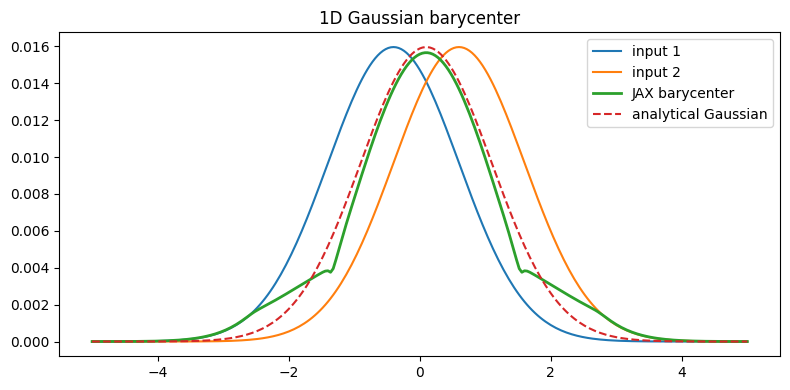

In [25]:
x = np.linspace(-5.0, 5.0, 251)
params_1d = [(-0.4, 1.0), (0.6, 1.0)]
weights_1d = np.array([0.5, 0.5])
measures_1d = np.stack([gaussian_1d(x, *param) for param in params_1d])

barycenter_1d, diagnostics_1d = solve_barycenter(
    measures_1d, (x,), weights_1d, reg=0.005, maxiter=10_000
)
target_mean_1d, target_std_1d = gaussian_barycenter_params_1d(params_1d, weights_1d)
actual_mean_1d, actual_std_1d = moments_1d(x, barycenter_1d)
target_curve_1d = gaussian_1d(x, target_mean_1d, target_std_1d)

print("diagnostic error:", float(diagnostics_1d["error"]))
print("target mean/std:", (target_mean_1d, target_std_1d))
print("actual mean/std:", (actual_mean_1d, actual_std_1d))

plt.figure(figsize=(8, 4))
plt.plot(x, measures_1d[0], label="input 1")
plt.plot(x, measures_1d[1], label="input 2")
plt.plot(x, barycenter_1d, label="JAX barycenter", linewidth=2)
plt.plot(x, target_curve_1d, "--", label="analytical Gaussian")
plt.title("1D Gaussian barycenter")
plt.legend()
plt.tight_layout()


## 1D POT comparison

The JAX solver uses the kernel `exp(-0.5 * d^2 / reg)`. To compare against `ot.bregman.barycenter`, we use the cost matrix `0.5 * d^2` with the same `reg`.

L1 difference: 1.5880880459815967e-07


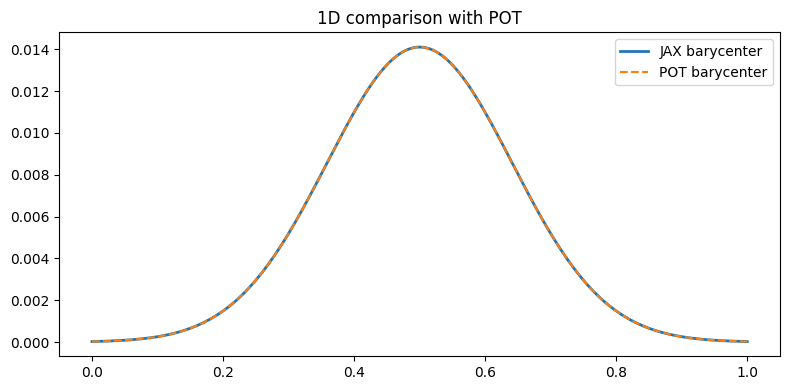

In [15]:
if ot is None:
    print("POT is not installed; skipping the POT comparison cell.")
else:
    x_pot = np.linspace(0.0, 1.0, 201)
    params_pot_1d = [(0.42, 0.10), (0.58, 0.10)]
    weights_pot_1d = np.array([0.5, 0.5])
    measures_pot_1d = np.stack([gaussian_1d(x_pot, *param) for param in params_pot_1d])

    barycenter_pot_1d, _ = solve_barycenter(
        measures_pot_1d, (x_pot,), weights_pot_1d, reg=0.01, maxiter=1000
    )
    cost_1d = 0.5 * ot.utils.dist(x_pot[:, None], x_pot[:, None], metric="sqeuclidean")
    pot_barycenter_1d = ot.bregman.barycenter(
        measures_pot_1d.T,
        cost_1d,
        reg=0.01,
        weights=weights_pot_1d,
        numItermax=10000,
        stopThr=1e-12,
    )

    print("L1 difference:", float(np.sum(np.abs(barycenter_pot_1d - pot_barycenter_1d))))

    plt.figure(figsize=(8, 4))
    plt.plot(x_pot, barycenter_pot_1d, label="JAX barycenter", linewidth=2)
    plt.plot(x_pot, pot_barycenter_1d, "--", label="POT barycenter")
    plt.title("1D comparison with POT")
    plt.legend()
    plt.tight_layout()


## 2D analytical Gaussian barycenter

For diagonal-covariance Gaussians on a regular product grid, the barycenter mean and axis-wise standard deviations are again the weighted averages of the inputs.

diagnostic error: 1.8884564269683324e-05
target moments: (0.13999999999999996, 0.12, 1.0, 1.0)
actual moments: (0.29762359828842827, 0.24267487172228724, 1.0383474782130901, 1.0257134228574307)


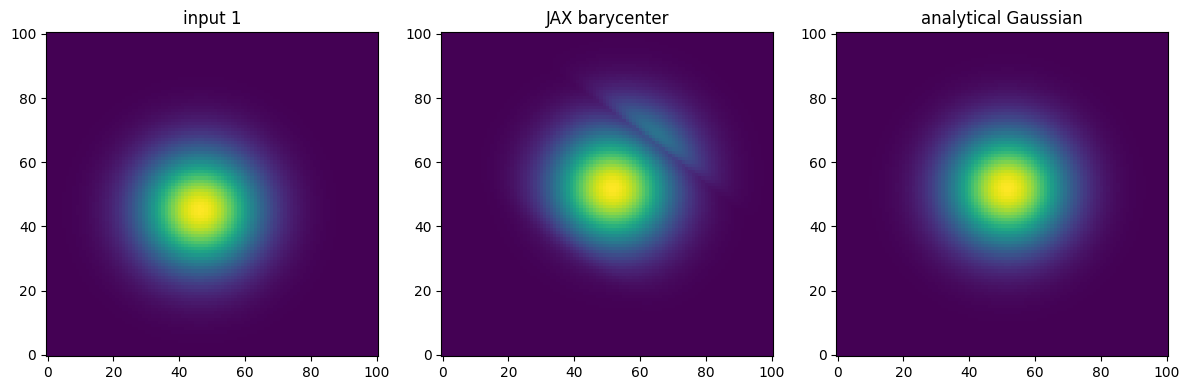

In [26]:
x2 = np.linspace(-4.0, 4.0, 101)
y2 = np.linspace(-4.0, 4.0, 101)
params_2d = [(-0.4, -0.3, 1.0, 1.0), (0.5, 0.4, 1.0, 1.0)]
weights_2d = np.array([0.4, 0.6])
measures_2d = np.stack([gaussian_2d(x2, y2, *param) for param in params_2d])

barycenter_2d, diagnostics_2d = solve_barycenter(
    measures_2d, (x2, y2), weights_2d, reg=0.01, maxiter=2000
)
target_2d = gaussian_barycenter_params_2d(params_2d, weights_2d)
actual_2d = moments_2d(x2, y2, barycenter_2d)
target_surface_2d = gaussian_2d(x2, y2, *target_2d)

print("diagnostic error:", float(diagnostics_2d["error"]))
print("target moments:", target_2d)
print("actual moments:", actual_2d)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(measures_2d[0], origin="lower", aspect="auto")
axes[0].set_title("input 1")
axes[1].imshow(barycenter_2d, origin="lower", aspect="auto")
axes[1].set_title("JAX barycenter")
axes[2].imshow(target_surface_2d, origin="lower", aspect="auto")
axes[2].set_title("analytical Gaussian")
plt.tight_layout()


## 2D POT convolutional comparison

POT's `convolutional_barycenter2d` uses the kernel `exp(-d^2 / reg)` on normalized image coordinates. To match the current JAX solver, we therefore compare `reg_pot = 2 * reg_jax` on a grid in `[0, 1]^2`.

L1 difference: 0.0018286066909531766


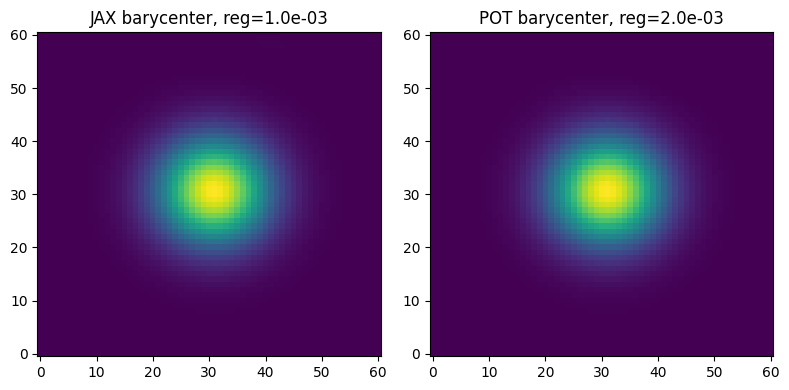

In [36]:
if ot is None:
    print("POT is not installed; skipping the POT 2D comparison cell.")
else:
    x_pot_2d = np.linspace(0.0, 1.0, 61)
    y_pot_2d = np.linspace(0.0, 1.0, 61)
    params_pot_2d = [(0.40, 0.45, 0.10, 0.12), (0.62, 0.58, 0.12, 0.10)]
    weights_pot_2d = np.array([0.5, 0.5])
    measures_pot_2d = np.stack([
        gaussian_2d(x_pot_2d, y_pot_2d, *param) for param in params_pot_2d
    ])

    reg_jax = 1e-3
    reg_pot = 2.0 * reg_jax
    barycenter_pot_2d, _ = solve_barycenter(
        measures_pot_2d, (x_pot_2d, y_pot_2d), weights_pot_2d, reg=reg_jax, maxiter=1000
    )
    pot_barycenter_2d = ot.bregman.convolutional_barycenter2d(
        measures_pot_2d,
        reg=reg_pot,
        weights=weights_pot_2d,
        numItermax=10000,
        stopThr=1e-12,
    )

    print("L1 difference:", float(np.sum(np.abs(barycenter_pot_2d - pot_barycenter_2d))))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(barycenter_pot_2d, origin="lower", aspect="auto")
    axes[0].set_title(f"JAX barycenter, reg={reg_jax:.1e}")
    axes[1].imshow(pot_barycenter_2d, origin="lower", aspect="auto")
    axes[1].set_title(f"POT barycenter, reg={reg_pot:.1e}")
    plt.tight_layout()


L1 difference: 0.16831710589317112


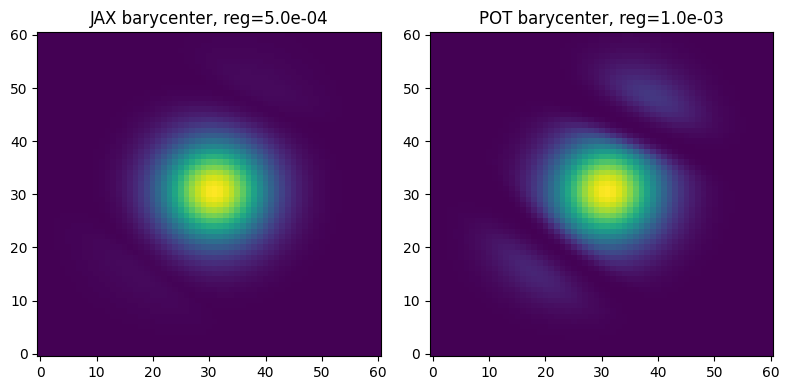

In [38]:
if ot is None:
    print("POT is not installed; skipping the POT 2D comparison cell.")
else:
    x_pot_2d = np.linspace(0.0, 1.0, 61)
    y_pot_2d = np.linspace(0.0, 1.0, 61)
    params_pot_2d = [(0.40, 0.45, 0.10, 0.12), (0.62, 0.58, 0.12, 0.10)]
    weights_pot_2d = np.array([0.5, 0.5])
    measures_pot_2d = np.stack([
        gaussian_2d(x_pot_2d, y_pot_2d, *param) for param in params_pot_2d
    ])

    reg_jax = 5e-4
    reg_pot = 2.0 * reg_jax
    barycenter_pot_2d, _ = solve_barycenter(
        measures_pot_2d, (x_pot_2d, y_pot_2d), weights_pot_2d, reg=reg_jax, maxiter=1000
    )
    pot_barycenter_2d = ot.bregman.convolutional_barycenter2d(
        measures_pot_2d,
        reg=reg_pot,
        weights=weights_pot_2d,
        numItermax=10000,
        stopThr=1e-12,
    )

    print("L1 difference:", float(np.sum(np.abs(barycenter_pot_2d - pot_barycenter_2d))))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(barycenter_pot_2d, origin="lower", aspect="auto")
    axes[0].set_title(f"JAX barycenter, reg={reg_jax:.1e}")
    axes[1].imshow(pot_barycenter_2d, origin="lower", aspect="auto")
    axes[1].set_title(f"POT barycenter, reg={reg_pot:.1e}")
    plt.tight_layout()
